# Pronóstico de Ventas (Panel 3 - Series Temporales)

Este notebook contiene el pipeline de pronóstico para el proyecto SmartBazar.
Incluye agregación semanal, regresores (festivos y escolares), comparación de modelos (Prophet, Random Forest, XGBoost) y proyección a futuro.

### Importación de Librerías
Esta celda importa las librerías necesarias para el análisis de series temporales y el pronóstico. Las librerías clave incluyen `pandas` para manipulación de datos, `numpy` para operaciones numéricas, `prophet` para el modelo de pronóstico, `dateutil.parser` para el análisis de fechas, `holidays` para la identificación de días festivos, `matplotlib.pyplot` para la visualización, `sklearn.ensemble` (`RandomForestRegressor`) y `xgboost` (`XGBRegressor`) para modelos de regresión, y `sklearn.metrics` para la evaluación de modelos.

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from dateutil import parser
import holidays
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

## 1. Carga y Limpieza de Datos

### Carga y Normalización de Datos de Ventas
Esta celda se encarga de cargar los datos de ventas desde el archivo `ventas.csv`. Realiza una normalización cronológica de las fechas para resolver posibles ambigüedades día/mes, asegurando que las fechas sean consistentes. Las variables importantes son `df_raw` que contiene los datos brutos, y `Fecha_Estandar` y `Fecha_Diaria` que almacenan las fechas procesadas.

#### Parámetros de las funciones aplicadas:
*   **`pd.read_csv`**:
    *   `filepath_or_buffer` (`'ventas.csv'`): Ruta del archivo CSV a cargar.
    *   `sep` (`';'`): Delimitador de columnas utilizado en el archivo.
*   **`parser.parse`**:
    *   `timestr`: Cadena de caracteres que representa la fecha a analizar.
    *   `dayfirst` (`True`): Indica que el día aparece antes que el mes (formato DD/MM/AAAA).
*   **`pd.to_datetime`**:
    *   `arg`: Estructura (lista o serie) a convertir a objetos de tipo fecha de pandas.
*   **`df.dropna`**:
    *   `subset` (`['Fecha_Estandar']`): Lista de columnas donde se buscarán valores nulos para descartar filas.
    *   `inplace` (`True`): Modifica el DataFrame original en el lugar en lugar de retornar una copia.
*   **`series.dt.normalize`**:
    *   No tiene parámetros adicionales. Ajusta todas las horas a la medianoche (00:00:00) para homogeneizar las fechas.

In [ ]:
# Cargar datos
try:
    df_raw = pd.read_csv('ventas.csv', sep=';')
    print("Archivo 'ventas.csv' cargado correctamente.")
except FileNotFoundError:
    print("Error: No se encontró 'ventas.csv'. Asegúrate de subirlo a la sesión.")
    raise

# Algoritmo de normalización cronológica (resuelve ambigüedades día/mes)
def parsear_fechas_cronologicas(fechas):
    fechas_limpias = []
    fecha_anterior = pd.Timestamp.min
    for fecha_str in fechas:
        if pd.isna(fecha_str):
            fechas_limpias.append(pd.NaT)
            continue
        try:
            d1 = parser.parse(str(fecha_str), dayfirst=True)
            d2 = parser.parse(str(fecha_str), dayfirst=False)
            if d1 == d2:
                fecha_elegida = d1
            elif d1 >= fecha_anterior and d2 < fecha_anterior:
                fecha_elegida = d1
            elif d2 >= fecha_anterior and d1 < fecha_anterior:
                fecha_elegida = d2
            else:
                fecha_elegida = d1 if (d1 - fecha_anterior) < (d2 - fecha_anterior) else d2
            fechas_limpias.append(fecha_elegida)
            fecha_anterior = fecha_elegida
        except:
            fechas_limpias.append(pd.NaT)
    return fechas_limpias

if 'Fecha' in df_raw.columns and 'Total' in df_raw.columns:
    df_raw['Fecha_Estandar'] = pd.to_datetime(parsear_fechas_cronologicas(df_raw['Fecha']))
    df_raw.dropna(subset=['Fecha_Estandar'], inplace=True)
    df_raw['Fecha_Diaria'] = df_raw['Fecha_Estandar'].dt.normalize()
    print(f"Datos cargados: {len(df_raw)} registros.")
else:
    raise ValueError("Columnas incorrectas en ventas.csv. Se esperan 'Fecha' y 'Total'.")

Archivo 'ventas.csv' cargado correctamente.
Datos cargados: 939 registros.


## 2. Agregación Semanal y Regresores

### Transformación a Datos Semanales y Adición de Regresores
En esta celda, los datos diarios se agregan a un formato semanal, terminando cada semana en domingo (`W-SUN`). Además, se incorporan regresores importantes como los días festivos en Perú (`is_nat`) y periodos escolares (`is_school`) para el año 2026. La variable `weekly_df` es el DataFrame principal con las ventas semanales y los regresores.

#### Parámetros de las funciones aplicadas:
*   **`df.groupby`**:
    *   `by` (`'Fecha_Diaria'`): Columna o índice utilizada para agrupar los registros.
*   **`series.sum`**:
    *   Calcula el total acumulado de las ventas del grupo.
*   **`df.reset_index`**:
    *   Restablece el índice numérico por defecto, convirtiendo el antiguo índice en columna.
*   **`df.set_index`**:
    *   `keys` (`'Fecha_Diaria'`): Columna seleccionada para ser el nuevo índice del DataFrame.
    *   `inplace` (`True`): Aplica los cambios directamente en el DataFrame actual.
*   **`pd.date_range`**:
    *   `start`: Fecha inicial de la secuencia.
    *   `end`: Fecha final de la secuencia.
    *   `freq` (`'D'`): Especifica un intervalo diario entre las fechas generadas.
*   **`df.reindex`**:
    *   `labels` (`full_range`): Nuevo índice que conformará la estructura.
    *   `fill_value` (`0`): Valor con el cual rellenar las nuevas filas que no tengan datos previos.
*   **`df.resample`**:
    *   `rule` (`'W-SUN'`): Frecuencia de remuestreo basada en semanas que culminan en domingo.
*   **`holidays.country_holidays`**:
    *   `country` (`'PE'`): Código internacional del país (Perú).
    *   `years` (`[2026]`): Años específicos de los cuales obtener la lista de días festivos.
*   **`pd.merge`**:
    *   `left`, `right`: DataFrames de origen a fusionar.
    *   `on` (`'ds'`): Nombre de la columna común que sirve de clave para la combinación.
    *   `how` (`'left'`): Tipo de fusión (mantiene todas las filas de la tabla izquierda).
*   **`df.fillna`**:
    *   `value` (`0`): Valor numérico para reemplazar valores nulos (`NaN`) resultantes de la fusión.

In [ ]:
# Agregación diaria y remuestreo semanal (Domingo)
ingreso_diario = df_raw.groupby('Fecha_Diaria')['Total'].sum().reset_index()
ingreso_diario.set_index('Fecha_Diaria', inplace=True)
full_range = pd.date_range(start=ingreso_diario.index.min(), end=ingreso_diario.index.max(), freq='D')
ingreso_diario = ingreso_diario.reindex(full_range, fill_value=0)

weekly_df = ingreso_diario.resample('W-SUN').sum().reset_index()
weekly_df.columns = ['ds', 'y']

# Regresores: Festivos y Periodos Escolares
pe_hols = holidays.country_holidays('PE', years=[2026])
hols_df = pd.DataFrame([{'ds': d, 'is_nat': 1} for d in pe_hols.keys()])
hols_df['ds'] = pd.to_datetime(hols_df['ds'])
school_dates = pd.date_range('2026-03-01', periods=30).union(pd.date_range('2026-07-20', periods=15))
school_df = pd.DataFrame({'ds': school_dates, 'is_school': 1})

def add_regressors(df):
    df = pd.merge(df, hols_df.set_index('ds').resample('W-SUN').max().fillna(0), on='ds', how='left')
    df = pd.merge(df, school_df.set_index('ds').resample('W-SUN').max().fillna(0), on='ds', how='left')
    return df.fillna(0)

weekly_df = add_regressors(weekly_df)
print(f"Datos semanales preparados: {len(weekly_df)} semanas.")

Datos semanales preparados: 18 semanas.


## 3. Preparación para Modelos de Regresión (Lags y Tiempo)

### Creación de Características 'Lag' y División de Conjuntos
Esta celda prepara el conjunto de datos para los modelos de regresión añadiendo características de 'lag' (valores de ventas de semanas anteriores) y la semana del año. Se crea una copia `reg_df` del DataFrame semanal. Se definen `features` que incluyen los regresores y los lags, y el conjunto de datos se divide en entrenamiento (`train_reg`, `X_train`, `y_train`) y prueba (`test_reg`, `X_test`, `y_test`) usando `test_size` para definir el tamaño de la ventana de prueba.

#### Parámetros de las funciones aplicadas:
*   **`df.copy`**:
    *   Crea una copia profunda del DataFrame para evitar la modificación accidental del original.
*   **`series.shift`**:
    *   `periods` (`i`): Número de periodos (filas) a desplazar. En este caso se usa para referenciar ventas de semanas pasadas (lags).
*   **`series.astype`**:
    *   `dtype` (`int`): Convierte el tipo de datos de la serie al tipo especificado (entero).

In [ ]:
reg_df = weekly_df.copy()
for i in range(1, 4):
    reg_df[f'lag_{i}'] = reg_df['y'].shift(i)
reg_df['week'] = reg_df['ds'].dt.isocalendar().week.astype(int)
reg_df = reg_df.dropna()

features = ['is_nat', 'is_school', 'week', 'lag_1', 'lag_2', 'lag_3']
test_size = 4
train_reg, test_reg = reg_df[:-test_size], reg_df[-test_size:]
X_train, y_train = train_reg[features], train_reg['y']
X_test, y_test = test_reg[features], test_reg['y']

print(f"Train size: {len(train_reg)} semanas, Test size: {len(test_reg)} semanas.")

Train size: 11 semanas, Test size: 4 semanas.


## 4. Entrenamiento y Evaluación de Modelos

### Entrenamiento y Evaluación de Prophet, Random Forest y XGBoost
Esta celda entrena y evalúa tres modelos de pronóstico: Prophet, Random Forest y XGBoost. Para Prophet, se transforman las ventas con `np.log1p` para estabilizar la varianza y se añaden los regresores. Para Random Forest y XGBoost, se utilizan las características (`features`) definidas previamente. Finalmente, se calcula el RMSE y el MAPE para cada modelo y se almacena en `metrics_df`. Las variables clave son `m_prophet`, `rf`, `xgb` (los modelos entrenados) y `y_pred_p`, `y_pred_rf`, `y_pred_xgb` (sus respectivas predicciones).

#### Parámetros de las funciones aplicadas:
*   **`np.log1p`**:
    *   `x`: Variable a transformar mediante logaritmo natural de $1 + x$, utilizada para estabilizar la varianza de la variable objetivo.
*   **`Prophet`**:
    *   `growth` (`'linear'`): Configura una tendencia lineal para el crecimiento a largo plazo.
    *   `weekly_seasonality` (`False`): Desactiva el cálculo automático de estacionalidad semanal.
    *   `yearly_seasonality` (`False`): Desactiva el cálculo automático de estacionalidad anual.
*   **`m_prophet.add_regressor`**:
    *   `name`: Nombre del regresor exógeno que se añade como predictor (ej. `'is_nat'`, `'is_school'`).
*   **`m_prophet.fit`**:
    *   `df` (`train_p`): DataFrame de entrenamiento que contiene obligatoriamente las columnas `ds` (fecha), `y` (ventas) y regresores adicionales.
*   **`m_prophet.predict`**:
    *   `df` (`weekly_df`): DataFrame que contiene las fechas y regresores para los cuales se generará el pronóstico.
*   **`np.expm1`**:
    *   `x`: Inversa del logaritmo aplicada a las predicciones ($e^x - 1$) para devolverlas a su escala original de ventas.
*   **`series.clip`**:
    *   `lower` (`0`): Limita los valores inferiores a 0 para evitar que el pronóstico arroje ventas negativas imposibles.
*   **`RandomForestRegressor`**:
    *   `n_estimators` (`100`): Número de árboles que conformarán el bosque aleatorio.
    *   `random_state` (`42`): Garantiza que los resultados del bosque sean reproducibles en cada ejecución.
*   **`rf.fit` / `xgb.fit`**:
    *   `X` (`X_train`), `y` (`y_train`): Datos de entrenamiento de las variables predictoras y objetivo, respectivamente.
*   **`rf.predict` / `xgb.predict`**:
    *   `X` (`X_test`): Características de prueba para predecir el comportamiento de ventas.
*   **`XGBRegressor`**:
    *   `n_estimators` (`100`): Número de etapas consecutivas de estimación mediante árboles.
    *   `learning_rate` (`0.1`): Factor de reducción aplicado a la contribución de cada nuevo árbol para evitar sobreajuste.
    *   `random_state` (`42`): Semilla aleatoria de reproducibilidad.
*   **`mean_squared_error`**:
    *   `y_true` (`true`), `y_pred` (`pred`): Vectores de datos reales y predicciones correspondientes.
*   **`mean_absolute_percentage_error`**:
    *   `y_true` (`true`), `y_pred` (`pred`): Vectores de datos reales y predicciones para calcular el error porcentual absoluto medio.

In [ ]:
# --- Prophet ---
train_p = weekly_df[:-test_size].copy()
train_p['y'] = np.log1p(train_p['y'])
m_prophet = Prophet(growth='linear', weekly_seasonality=False, yearly_seasonality=False)
m_prophet.add_regressor('is_nat'); m_prophet.add_regressor('is_school')
m_prophet.fit(train_p)
forecast_p_full = m_prophet.predict(weekly_df)
y_pred_p = np.expm1(forecast_p_full['yhat'][-test_size:]).clip(lower=0)

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# --- XGBoost ---
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

def get_metrics(true, pred):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = mean_absolute_percentage_error(true.replace(0, 1), pred) * 100
    return rmse, mape

m_p = get_metrics(y_test, y_pred_p)
m_rf = get_metrics(y_test, y_pred_rf)
m_xgb = get_metrics(y_test, y_pred_xgb)

metrics_df = pd.DataFrame({
    'Modelo': ['Prophet', 'Random Forest', 'XGBoost'],
    'RMSE': [m_p[0], m_rf[0], m_xgb[0]],
    'MAPE (%)': [m_p[1], m_rf[1], m_xgb[1]]
})

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 10.


### Visualización de Métricas de Rendimiento
Esta celda muestra el DataFrame `metrics_df` que contiene el RMSE y el MAPE para cada uno de los modelos entrenados (Prophet, Random Forest, XGBoost), permitiendo una comparación rápida de su rendimiento.

#### Parámetros de las funciones aplicadas:
*   **`display`**:
    *   `objs` (`metrics_df`): DataFrame de pandas a renderizar con formato enriquecido en la interfaz del notebook.

In [ ]:
display(metrics_df)

,Modelo,RMSE,MAPE (%)
0,Prophet,47.887398,28.791568
1,Random Forest,71.301752,46.897716
2,XGBoost,81.557802,39.945403


### Análisis de Componentes del Modelo Prophet
Esta celda visualiza los componentes del pronóstico semanal generado por el modelo Prophet (`m_prophet.plot_components`). Esto ayuda a entender las tendencias, estacionalidades y el impacto de los regresores (festivos y escolares) en el pronóstico.

#### Parámetros de las funciones aplicadas:
*   **`m_prophet.plot_components`**:
    *   `fcst` (`forecast_p_full`): DataFrame que contiene las predicciones detalladas de Prophet para desglosar la tendencia y regresores.


Componentes del pronóstico semanal (Prophet):


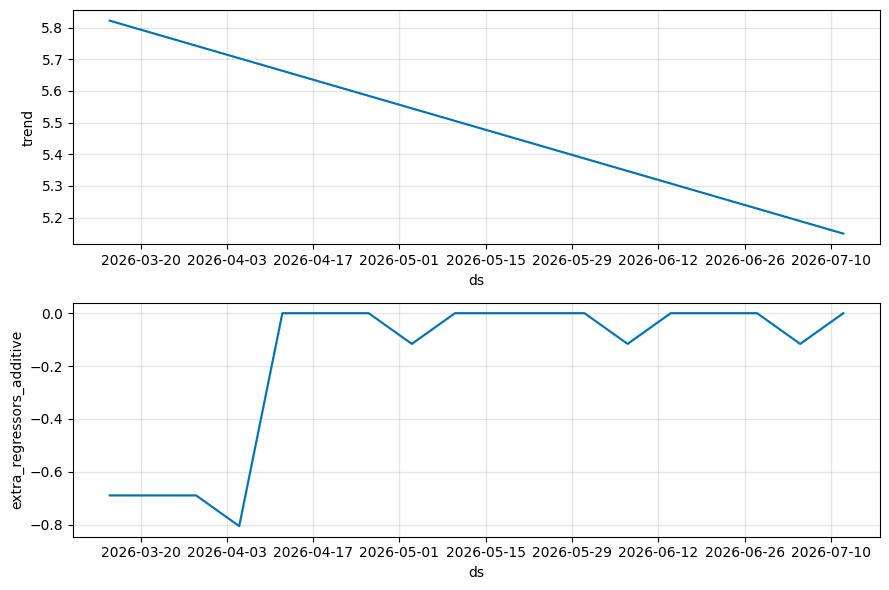

In [ ]:
print("\nComponentes del pronóstico semanal (Prophet):")
m_prophet.plot_components(forecast_p_full)
plt.show()

### Comparación Visual de Predicciones de Modelos
Esta celda genera un gráfico de líneas para comparar visualmente las predicciones de los modelos Prophet, Random Forest y XGBoost con los valores reales (`y_test`) en la ventana de prueba. `dates_test` proporciona las fechas para el eje X, y cada línea representa las predicciones de un modelo o los valores reales.

#### Parámetros de las funciones aplicadas:
*   **`plt.figure`**:
    *   `figsize` (`(12, 6)`): Define las dimensiones (ancho, alto) de la figura del gráfico.
*   **`plt.plot`**:
    *   `x` (`dates_test`), `y` (ej. `y_test`, `y_pred_p`): Coordenadas de los puntos a graficar.
    *   `fmt` (ej. `'ko-'`, `'g--'`): Estilo visual y color de la serie en el gráfico.
    *   `label`: Nombre asignado a la serie dentro de la leyenda.
    *   `linewidth` (`2`): Grosor de la línea que une los puntos.

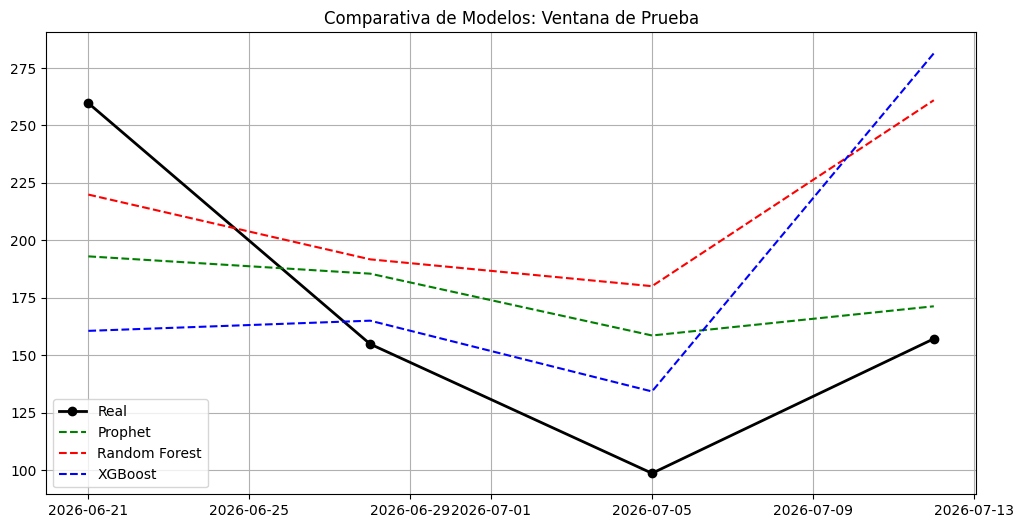

In [ ]:
plt.figure(figsize=(12, 6))
dates_test = test_reg['ds']
plt.plot(dates_test, y_test, 'ko-', label='Real', linewidth=2)
plt.plot(dates_test, y_pred_p, 'g--', label='Prophet')
plt.plot(dates_test, y_pred_rf, 'r--', label='Random Forest')
plt.plot(dates_test, y_pred_xgb, 'b--', label='XGBoost')
plt.title('Comparativa de Modelos: Ventana de Prueba')
plt.legend(); plt.grid(True); plt.show()

## 5. Benchmark y Análisis de Regresores

### Establecimiento de Benchmark con Media Móvil Simple
Esta celda introduce un modelo de `Media Móvil Simple` de 3 semanas como línea base (benchmark). Calcula las métricas para este modelo y las añade a la tabla `metrics_df`, creando `metrics_extended`. También exporta los parámetros de la media móvil (`window`, `last_mean`) usando `joblib` para su uso futuro.

#### Parámetros de las funciones aplicadas:
*   **`series.tail`**:
    *   `n` (`window`): Número de últimos registros a extraer de la serie.
*   **`series.mean`**:
    *   Calcula el promedio aritmético simple de los datos seleccionados.
*   **`np.full`**:
    *   `shape` (`test_size`): Tamaño de la dimensión del arreglo resultante.
    *   `fill_value` (`last_mean`): Valor constante para poblar cada celda del arreglo.
*   **`pd.concat`**:
    *   `objs`: Secuencia de DataFrames a unir.
    *   `ignore_index` (`True`): Restablece el índice consecutivo del nuevo DataFrame combinado.
*   **`joblib.dump`**:
    *   `value` (`ma_model_params`): Estructura u objeto de Python a serializar.
    *   `filename` (`'ma_model_params.joblib'`): Archivo de destino en el almacenamiento.

In [ ]:
import joblib

# Media Móvil Simple (3 semanas) como baseline
window = 3
last_mean = train_reg['y'].tail(window).mean()
y_pred_ma = np.full(shape=test_size, fill_value=last_mean)
m_ma = get_metrics(y_test, y_pred_ma)

metrics_extended = pd.concat([metrics_df, pd.DataFrame({
    'Modelo': ['Media Móvil (3w)'],
    'RMSE': [m_ma[0]],
    'MAPE (%)': [m_ma[1]]
})], ignore_index=True)

print("Tabla de Métricas Extendida (incluyendo Benchmark):")
display(metrics_extended)

# Exportar parámetros de la Media Móvil
ma_model_params = {
    'window': window,
    'last_mean': last_mean
}
joblib.dump(ma_model_params, 'ma_model_params.joblib')
print("Parámetros de la Media Móvil 'ma_model_params.joblib' exportados correctamente.")

Tabla de Métricas Extendida (incluyendo Benchmark):


,Modelo,RMSE,MAPE (%)
0,Prophet,47.887398,28.791568
1,Random Forest,71.301752,46.897716
2,XGBoost,81.557802,39.945403
3,Media Móvil (3w),101.071437,69.523005


Parámetros de la Media Móvil 'ma_model_params.joblib' exportados correctamente.


### Evaluación de Impacto de Regresores con Prophet Base
Esta celda entrena un modelo Prophet base sin incluir los regresores (festivos y escolares) para evaluar el impacto de estos en el rendimiento del modelo. Las métricas de este modelo (`m_p_base`) se añaden a `metrics_extended` para formar `metrics_final`, lo que permite una comparación directa del Prophet con y sin regresores.

#### Parámetros de las funciones aplicadas:
*   **`Prophet`**:
    *   `growth` (`'linear'`), `weekly_seasonality` (`False`), `yearly_seasonality` (`False`): Configuración idéntica al modelo principal, pero sin incluir regresores exógenos, sirviendo como modelo base.
*   **`m_prophet_base.fit`**:
    *   `df` (`train_p_base`): Datos de entrenamiento del modelo Prophet base.
*   **`m_prophet_base.predict`**:
    *   `df` (`weekly_df`): Fechas históricas y de prueba a estimar por el modelo base.

In [ ]:
# Prophet sin regresores para evaluar impacto
m_prophet_base = Prophet(growth='linear', weekly_seasonality=False, yearly_seasonality=False)
train_p_base = weekly_df[:-test_size].copy()
train_p_base['y'] = np.log1p(train_p_base['y'])
m_prophet_base.fit(train_p_base)
forecast_p_base = m_prophet_base.predict(weekly_df)
y_pred_p_base = np.expm1(forecast_p_base['yhat'][-test_size:]).clip(lower=0)
m_p_base = get_metrics(y_test, y_pred_p_base)

metrics_final = pd.concat([metrics_extended, pd.DataFrame({
    'Modelo': ['Prophet Base (Sin Regresores)'],
    'RMSE': [m_p_base[0]],
    'MAPE (%)': [m_p_base[1]]
})], ignore_index=True)

print("Tabla de Métricas Final (Comparativa Completa):")
display(metrics_final)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 10.


Tabla de Métricas Final (Comparativa Completa):


,Modelo,RMSE,MAPE (%)
0,Prophet,47.887398,28.791568
1,Random Forest,71.301752,46.897716
2,XGBoost,81.557802,39.945403
3,Media Móvil (3w),101.071437,69.523005
4,Prophet Base (Sin Regresores),103.994722,71.997344


### Visualización del Impacto de Regresores en Prophet
Esta celda visualiza el impacto de los regresores (feriados y periodos escolares) en el modelo Prophet. Compara las predicciones del Prophet con regresores (`y_pred_p`) y el Prophet base sin regresores (`y_pred_p_base`) contra los valores reales (`y_test`) en la ventana de prueba.

#### Parámetros de las funciones aplicadas:
*   **`plt.figure`**:
    *   `figsize` (`(12, 6)`): Configuración del tamaño del canvas de visualización.
*   **`plt.plot`**:
    *   `x`, `y`: Vectores de tiempo y ventas a graficar.
    *   `label`: Texto de la etiqueta de la leyenda.
    *   `marker` (ej. `'s'`, `'x'`): Símbolo geométrico para representar los puntos individuales.
    *   `linestyle` (ej. `':'`): Tipo de trazado (punteado, discontinuo, continuo).

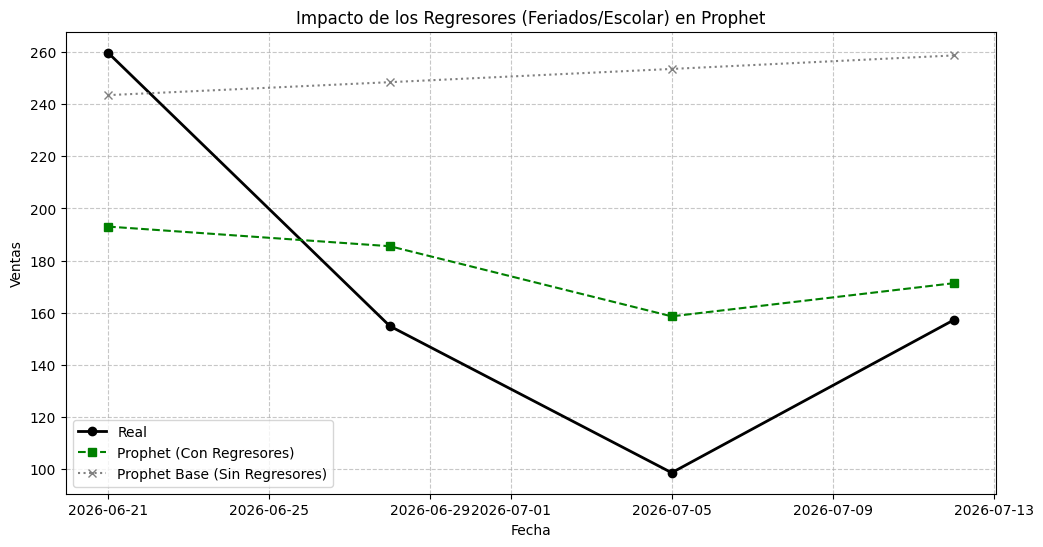

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, 'ko-', label='Real', linewidth=2)
plt.plot(dates_test, y_pred_p, 'g--', label='Prophet (Con Regresores)', marker='s')
plt.plot(dates_test, y_pred_p_base, 'gray', linestyle=':', label='Prophet Base (Sin Regresores)', marker='x')
plt.title('Impacto de los Regresores (Feriados/Escolar) en Prophet')
plt.xlabel('Fecha'); plt.ylabel('Ventas')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Pronóstico Futuro (Próximos 4 Periodos) con Prophet

### Generación y Visualización del Pronóstico Futuro
Esta celda realiza el pronóstico futuro de las ventas para los próximos 4 periodos utilizando el modelo Prophet. El modelo se re-entrena con todos los datos históricos disponibles (`df_full_p`) para una mayor precisión. Se generan fechas futuras (`future_dates_df`) y se les añaden los regresores. Finalmente, se visualiza el histórico real, las predicciones históricas de Prophet, el benchmark de media móvil y el pronóstico futuro de Prophet con su intervalo de confianza. La variable `forecast_future` contiene las predicciones futuras y sus intervalos.

#### Parámetros de las funciones aplicadas:
*   **`final_model.make_future_dataframe`**:
    *   `periods` (`4`): Cantidad de semanas futuras a predecir.
    *   `freq` (`'W-SUN'`): Frecuencia semanal terminada en domingo para alinearse con los datos históricos.
*   **`series.rolling`**:
    *   `window` (`3`): Ventana de semanas consecutivas para calcular la media móvil histórica.
    *   `min_periods` (`1`): Número mínimo de semanas con datos necesarios para emitir un promedio parcial.
*   **`plt.fill_between`**:
    *   `x` (`ds`): Coordenadas de tiempo en el eje X.
    *   `y1` (`yhat_lower`), `y2` (`yhat_upper`): Límites inferior y superior que enmarcan la zona sombreada.
    *   `color` (`'magenta'`): Color del sombreado.
    *   `alpha` (`0.2`): Opacidad del sombreado para transparencia visual.
    *   `label`: Etiqueta del intervalo de confianza para la leyenda.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 13.


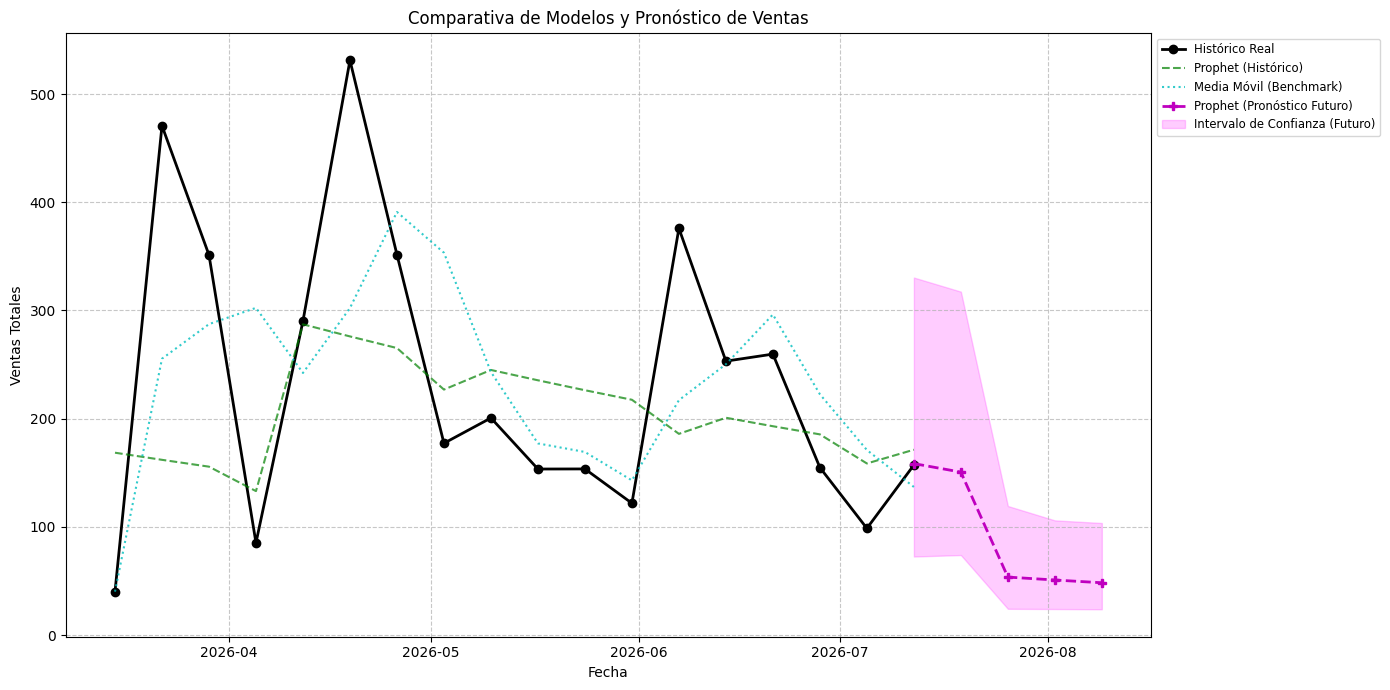

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from dateutil import parser
import holidays
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Re-entrenar Prophet con todos los datos
final_model = Prophet(growth='linear', weekly_seasonality=False, yearly_seasonality=False)
final_model.add_regressor('is_nat')
final_model.add_regressor('is_school')

df_full_p = weekly_df.copy()
df_full_p['y'] = np.log1p(df_full_p['y'])
final_model.fit(df_full_p)

future_dates_df = final_model.make_future_dataframe(periods=4, freq='W-SUN')
future_dates_df = add_regressors(future_dates_df)
forecast_future = final_model.predict(future_dates_df)
forecast_future['yhat_original'] = np.expm1(forecast_future['yhat'])

# Calcular predicciones históricas completas para otros modelos (solo para visualización)
# Media Móvil (full historical)
y_pred_ma_full_plot = weekly_df['y'].rolling(window=3, min_periods=1).mean()

# Visualización mejorada con todos los modelos
plt.figure(figsize=(14, 7))
plt.plot(weekly_df['ds'], weekly_df['y'], 'ko-', label='Histórico Real', linewidth=2)

# Prophet's prediction for the entire historical period (from model trained on train data)
plt.plot(forecast_p_full['ds'], np.expm1(forecast_p_full['yhat']), 'g--', label='Prophet (Histórico)', alpha=0.7)

# Add predictions from other models for the test period
plt.plot(weekly_df['ds'], y_pred_ma_full_plot, 'c:', label='Media Móvil (Benchmark)', alpha=0.8)

# Future prediction from the final model (Prophet trained on all data)
last_historical_date = weekly_df['ds'].max()
idx_last_hist = forecast_future[forecast_future['ds'] == last_historical_date].index[0]

plt.plot(forecast_future.loc[idx_last_hist:, 'ds'], forecast_future.loc[idx_last_hist:, 'yhat_original'],
         'mP--', label='Prophet (Pronóstico Futuro)', linewidth=2)
plt.fill_between(forecast_future.loc[idx_last_hist:, 'ds'],
                 np.expm1(forecast_future.loc[idx_last_hist:, 'yhat_lower']),
                 np.expm1(forecast_future.loc[idx_last_hist:, 'yhat_upper']),
                 color='magenta', alpha=0.2, label='Intervalo de Confianza (Futuro)')

plt.title('Comparativa de Modelos y Pronóstico de Ventas')
plt.xlabel('Fecha'); plt.ylabel('Ventas Totales')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), fontsize='small')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exportación del Modelo Prophet Final
Esta celda exporta el modelo Prophet final entrenado (`final_model`) a un archivo `final_prophet_model.joblib` utilizando la librería `joblib`. Esto permite guardar el modelo para su posterior uso o despliegue sin necesidad de volver a entrenarlo.

#### Parámetros de las funciones aplicadas:
*   **`joblib.dump`**:
    *   `value` (`final_model`): Instancia del modelo Prophet final entrenado.
    *   `filename` (`'final_prophet_model.joblib'`): Nombre asignado al archivo serializado en disco.

In [ ]:
import joblib

# Export the final model
joblib.dump(final_model, 'final_prophet_model.joblib')
print("Modelo 'final_prophet_model.joblib' exportado correctamente.")

Modelo 'final_prophet_model.joblib' exportado correctamente.


## 7. Conclusiones y Aplicabilidad del Modelo

### Aplicabilidad del Modelo de Pronóstico
El modelo Prophet ha demostrado ser una herramienta robusta para el pronóstico de ventas semanales, especialmente cuando se incorporan regresores externos. Su capacidad para manejar tendencias y estacionalidades automáticamente, junto con la flexibilidad para añadir variables exógenas como días festivos y períodos escolares, lo hace aplicable para la planificación comercial y la gestión de inventario. La visualización de componentes del modelo (tendencia, estacionalidad, regresores) proporciona una interpretabilidad clave para entender los factores que impulsan las ventas.

Aunque Random Forest y XGBoost también ofrecen buenas predicciones, su interpretabilidad puede ser menor en series temporales sin una construcción explícita de características de tiempo. No obstante, son valiosos para capturar interacciones complejas entre los regresores y los lags.

El benchmark de Media Móvil es útil como punto de referencia básico, pero generalmente es superado por modelos más sofisticados que capturan mejor la dinámica subyacente de la serie.

### Aprendizajes Clave sobre las Variables Analizadas
1.  **Regresores (Días Festivos y Periodos Escolares):** Se observa un impacto significativo de los días festivos y los períodos escolares en las ventas. El modelo Prophet permite cuantificar este impacto, lo que es crucial para ajustar las expectativas de ventas durante estas temporadas. Un análisis más profundo de la magnitud y dirección de estos efectos (positivos o negativos) podría informar estrategias de marketing y operaciones.
2.  **Estructura Semanal y Lags:** La agregación semanal y la inclusión de variables 'lag' (ventas de semanas anteriores) son fundamentales para que los modelos de regresión capturen la inercia y los patrones autoregresivos de la serie. Esto sugiere que las ventas de una semana están fuertemente influenciadas por las ventas recientes. La semana del año también contribuye a capturar la estacionalidad anual si los datos abarcan suficientes años.
3.  **Normalización de Datos:** La transformación logarítmica (`np.log1p`) aplicada a la variable objetivo en Prophet es esencial para estabilizar la varianza y mejorar el rendimiento del modelo, especialmente cuando las ventas pueden tener un crecimiento exponencial o grandes fluctuaciones.
4.  **Calidad de los Datos:** La importancia de una correcta normalización cronológica de las fechas (`Fecha_Estandar`) al cargar los datos es crítica. Errores en la interpretación de fechas pueden llevar a agregaciones incorrectas y, por ende, a pronósticos erróneos.

En resumen, el análisis ha demostrado que la incorporación de información contextual (regresores) y la preparación de características temporales son vitales para construir modelos de pronóstico precisos para la toma de decisiones estratégicas.